# Оценка вакантности по домам

Начало — в предыдущей тетрадке: там обучали модель, а здесь её применяют для оценки вакантности.

In [1]:
from collections import namedtuple
import pickle

import numpy as np
import pandas as pd
import tqdm

pd.set_option("display.max_columns", None)

## Загрузка и подготовка данных

- `flats_mapping` — соотнесение `id` домов и кадастровых номеров квартир.
- `flats_properties` — свойства квартир: кадастровый номер, площадь, этаж.
- `houses` — реестр домов из открытых данных ФРТ.
- `repair_data` — данные по капремонту из ФРТ.

In [2]:
flats_mapping = pd.read_parquet("flats.parquet")
flats_properties = pd.read_parquet("flats_area.parquet")
houses = pd.read_csv("../intercarto-intergis/data/export-reestrmkd-77-20250301.zip", sep=";", decimal=",")
repair_data = pd.read_csv("../intercarto-intergis/data/export-kr1_1-77-20250301.zip", sep=";", decimal=",")

In [3]:
houses.head(2)

,id,region_id,area_id,city_id,street_id,shortname_region,formalname_region,shortname_area,formalname_area,shortname_city,formalname_city,shortname_street,formalname_street,house_number,building,block,letter,address,houseguid,management_organization_id,built_year,exploitation_start_year,project_type,house_type,is_alarm,method_of_forming_overhaul_fund,floor_count_max,floor_count_min,entrance_count,elevators_count,energy_efficiency,quarters_count,living_quarters_count,unliving_quarters_count,area_total,area_residential,area_non_residential,area_common_property,area_land,parking_square,playground,sportsground,other_beautification,foundation_type,floor_type,wall_material,basement_area,chute_type,chute_count,electrical_type,electrical_entries_count,heating_type,hot_water_type,cold_water_type,sewerage_type,sewerage_cesspools_volume,gas_type,ventilation_type,firefighting_type,drainage_type
0,8649748,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,9,NaN,1,NaN,"г. Москва, д. 9, к. 1",521474b9-1d5a-702f-3b75-33ff10263733,7628409.0,1973.0,1973.0,П-49-04/70Д,Многоквартирный дом,Нет,На счете регионального оператора,9.0,9.0,4.0,4.0,Не присвоен,144,144.0,0.0,7219.0,4940.0,0.0,2279.0,0.0,0.0,500,500,NaN,Бетонные столбы,Железобетонные,Панельные,1159.0,На лестничной клетке,4.0,Центральное,1.0,Центральное,Закрытая с приготовлением горячей воды на ЦТП,Центральное,Центральное,0.0,Центральное,Вытяжная вентиляция,Отсутствует,Внутренние водостоки
1,9370109,0c5b2444-70a0-4932-980c-b4dc0d3f02b5,NaN,NaN,NaN,г,Москва,NaN,NaN,NaN,NaN,NaN,NaN,14,NaN,1,NaN,"г. Москва, д. 14, к. 1",64f12da8-00f6-ab7c-a849-2e1c3cccd26b,NaN,NaN,NaN,NaN,Не заполнено,Нет,Не заполнено,NaN,NaN,NaN,NaN,Не заполнено,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,498,498,NaN,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено,NaN,Не заполнено,Не заполнено,Не заполнено,Не заполнено


In [4]:
repair_data.head(2)

,subject_rf,mun_obr_oktmo,mun_obr,mkd_code,houseguid,address,commission_year,architectural_monument_category,total_sq,total_rooms_amount,living_rooms_amount,total_rooms_sq,living_rooms_sq,total_ppl,number_floors_max,money_collecting_way,money_ppl_collected,money_ppl_collected_debts,overhaul_funds_spent_all,overhaul_funds_spent_subsidy,overhaul_fund_spent_other,overhaul_funds_balance,update_date_of_information,money_ppl_collected_date,owners_payment,energy_efficiency,alarm_document_date,exclude_date_from_program,inclusion_date_to_program,comment,last_update,house_id
0,город Москва,45397000,Академический район,108367,fa844609-84ef-4f05-8414-74b25c56fce1,60-летия Октября просп. 10/1,1964,NaN,3448.0,71,68,3352.46,2429.13,136,9,Счет регионального оператора,7059.18318,22.57946,1597.26244,NaN,NaN,5461.92074,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004177.0
1,город Москва,45397000,Академический район,104062,6793bac3-20b7-4e42-b53a-73dc9be6c309,60-летия Октября просп. 12,1963,NaN,3457.0,75,68,3251.41,2539.72,129,9,Счет регионального оператора,6772.90899,90.33989,13380.14323,NaN,NaN,-6607.23424,2025-01-15,01.01.2015,29.66,NaN,NaN,NaN,29.12.2014,NaN,23.01.2025,8004180.0


In [5]:
flats_mapping.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5318579 entries, 0 to 5318578
Data columns (total 2 columns):
 #   Column                                            Dtype 
---  ------                                            ----- 
 0   Глобальный уникальный идентификатор дома по ФИАС  object
 1   Кадастровый номер                                 object
dtypes: object(2)
memory usage: 81.2+ MB


In [6]:
flats_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4952236 entries, 0 to 92449
Data columns (total 3 columns):
 #   Column           Dtype  
---  ------           -----  
 0   flat_cad_number  object 
 1   flat_area        int64  
 2   flat_floor       float64
dtypes: float64(1), int64(1), object(1)
memory usage: 151.1+ MB


In [7]:
flats_mapping.columns = ["houseguid", "flat_cad_number"]
flats = flats_mapping.merge(flats_properties)
flats.dropna(inplace=True)
flats["flat_area"] = flats["flat_area"].round()
flats.rename(columns={"flat_area": "flat_area_total"}, inplace=True)
flats[flats.select_dtypes(float).columns] = flats.select_dtypes(float).astype(int)
flats.drop(columns=["flat_cad_number"], inplace=True)
flats.head()

,houseguid,flat_area_total,flat_floor
0,021f35f5-fe8e-4291-b7f1-48eecca62b6e,87,2
1,021f35f5-fe8e-4291-b7f1-48eecca62b6e,123,2
2,021f35f5-fe8e-4291-b7f1-48eecca62b6e,91,2
3,021f35f5-fe8e-4291-b7f1-48eecca62b6e,228,2
4,021f35f5-fe8e-4291-b7f1-48eecca62b6e,154,2


In [8]:
flats.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4571219 entries, 0 to 4573345
Data columns (total 3 columns):
 #   Column           Dtype 
---  ------           ----- 
 0   houseguid        object
 1   flat_area_total  int64 
 2   flat_floor       int64 
dtypes: int64(2), object(1)
memory usage: 139.5+ MB


Выбираем признаки, соответствующие тем, на которых обучалась модель, и приводим их к тому же типу и «размерности».

In [9]:
houses_properties = houses[["houseguid"]].copy()
houses_properties["house_construction_year"] = pd.cut(
    x=houses["built_year"],
    bins=[1147, 1920, 1945, 1956, 1970, 1995, 2012, 2026],
    labels=[1, 2, 3, 4, 5, 6, 7],
).astype(float)
houses_properties["house_is_alarm"] = houses["is_alarm"] == "Да"
houses_properties["house_has_elevator"] = houses["elevators_count"] > 0
houses_properties["house_has_chute"] = houses["chute_count"] > 0
houses_properties["house_has_parking"] = houses["parking_square"] > 0
houses_properties["house_has_playground"] = houses["playground"].map({
    499: True,
    500: False,
    498: np.nan,
})
houses_properties["house_has_sportsground"] = houses["sportsground"].map({
    499: True,
    500: False,
    498: np.nan,
})
houses_properties["house_wall_material"] = houses["wall_material"].map({
    "Кирпич": 1,
    "Железобетон": 2,
    "Блочные": 2,
    "Панельные": 2,
    "Монолитные": 3,
    "Смешанные": 5,
    "Деревянные": 4,
    "Иные": 6,
    "Железобетонная панель": 2,
    "Шлакобетон (блоки)": 2,
    "Керамзитобетон": 2,  
})
houses_properties["house_cold_water_type"] = houses["cold_water_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_hot_water_type"] = houses["hot_water_type"].map({
    "Закрытая с приготовлением горячей воды на ЦТП": 1,                                
    "Открытая с отбором сетевой воды на горячее водоснабжение из тепловой сети": 2,
    "Отсутствует": 3,                                                                 
    "Квартирное (квартирный котел)": 2,                                                
    "Закрытая с приготовлением горячей воды на ИТП": 2,                                  
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,                        
    "Печное": 2,
})
houses_properties["house_heating_type"] = houses["heating_type"].map({
    "Центральное": 1,
    "Квартирное отопление (квартирный котел)": 2,
    "Автономная котельная (крышная, встроенно-пристроенная)": 2,
    "Индивидуальный тепловой пункт (ИТП)": 2,
    "Отсутствует": 4,
    "Печное": 3,
})
houses_properties["house_serwage_type"] = houses["sewerage_type"].map({
    "Центральное": 1,
    "Отсутствует": 4,
    "Автономное": 2,
})
houses_properties["house_has_gas"] = houses["gas_type"].map({
    "Центральное": True,
    "Отсутствует": False,
    "Автономное": True,
})

houses_properties.dropna(inplace=True)
houses_properties[houses_properties.select_dtypes(float).columns] = houses_properties.select_dtypes(float).astype(int)
houses_properties["house_has_gas"] = houses_properties["house_has_gas"].astype(bool)
houses_properties["house_has_playground"] = houses_properties["house_has_playground"].astype(bool)
houses_properties["house_has_sportsground"] = houses_properties["house_has_sportsground"].astype(bool)

houses_properties.head()

,houseguid,house_construction_year,house_is_alarm,house_has_elevator,house_has_chute,house_has_parking,house_has_playground,house_has_sportsground,house_wall_material,house_cold_water_type,house_hot_water_type,house_heating_type,house_serwage_type,house_has_gas
0,521474b9-1d5a-702f-3b75-33ff10263733,5,False,True,True,False,False,False,2,1,1,1,1,True
3,4b9cbbad-b371-6ce1-bebe-09e785d0b894,5,False,True,True,False,True,True,2,1,1,1,1,False
11,723e2dcf-d203-4dc1-89de-9b41f453916a,1,False,False,True,False,False,False,1,1,2,1,1,True
12,8425ff55-ec42-466a-a993-de4e5faaba3b,4,False,True,True,False,False,False,1,1,1,1,1,True
13,a8ad9e0b-e0c1-46a7-981c-4d5a598c76ce,3,False,True,True,False,False,False,1,1,1,1,1,True


In [10]:
houses_properties.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31959 entries, 0 to 34702
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   houseguid                31959 non-null  object
 1   house_construction_year  31959 non-null  int64 
 2   house_is_alarm           31959 non-null  bool  
 3   house_has_elevator       31959 non-null  bool  
 4   house_has_chute          31959 non-null  bool  
 5   house_has_parking        31959 non-null  bool  
 6   house_has_playground     31959 non-null  bool  
 7   house_has_sportsground   31959 non-null  bool  
 8   house_wall_material      31959 non-null  int64 
 9   house_cold_water_type    31959 non-null  int64 
 10  house_hot_water_type     31959 non-null  int64 
 11  house_heating_type       31959 non-null  int64 
 12  house_serwage_type       31959 non-null  int64 
 13  house_has_gas            31959 non-null  bool  
dtypes: bool(7), int64(6), object(1)
memory usag

Собираем поквартирную таблицу: строка = квартира, индивидуальные свойства + свойства дома. Убираем заведомо выбросы.

In [16]:
flats_with_house_info = flats.merge(houses_properties)
flats_with_house_info["region_code"] = 45
flats_with_house_info = flats_with_house_info.merge(repair_data[["houseguid", "total_ppl"]])
flats_with_house_info = flats_with_house_info.loc[
    (flats_with_house_info["flat_area_total"] > 10) & (flats_with_house_info["flat_area_total"] < 250)
    & (flats_with_house_info["flat_floor"] >= 1) & (flats_with_house_info["flat_floor"] < 75)
    & (flats_with_house_info["total_ppl"] > 10) & (flats_with_house_info["total_ppl"] < 3000)
]
flats_with_house_info.rename(columns={"total_ppl": "house_total_ppl"}, inplace=True)
flats_with_house_info.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3170376 entries, 0 to 3410589
Data columns (total 18 columns):
 #   Column                   Dtype 
---  ------                   ----- 
 0   houseguid                object
 1   flat_area_total          int64 
 2   flat_floor               int64 
 3   house_construction_year  int64 
 4   house_is_alarm           bool  
 5   house_has_elevator       bool  
 6   house_has_chute          bool  
 7   house_has_parking        bool  
 8   house_has_playground     bool  
 9   house_has_sportsground   bool  
 10  house_wall_material      int64 
 11  house_cold_water_type    int64 
 12  house_hot_water_type     int64 
 13  house_heating_type       int64 
 14  house_serwage_type       int64 
 15  house_has_gas            bool  
 16  region_code              int64 
 17  house_total_ppl          int64 
dtypes: bool(7), int64(10), object(1)
memory usage: 311.4+ MB


In [12]:
flats_with_house_info["houseguid"].nunique()

23090

## Оценка вакантности

1. Берём дом.
2. Перебираем квартиры в произвольном порядке (считаем, что порядок в данных подходит, так как не зависит от свойств квартиры) и просим модель предсказать распределение вероятностей того или иного числа жителей.
3. Из этого распределения случайным образом извлекаем число жителей в данной квартире.
4. Суммируем полученные числа до тех пор, пока не получим число жителей в доме. Если остановились, и в доме ещё остались квартиры, то считаем их вакантными, иначе вакантных квартир 0. Если не остановились, и квартиры в доме закончились, то вакантных квартир 0.
5. Повторяем так 1000 раз, получая разные оценки числа вакантных квартир. Агрегируем их: считаем среднее, медиану, стандартное отклонение.

В коде это выглядит по-другому для оптимизации, но суть та же.

In [18]:
with open("model.dump", "rb") as f:
    rfc = pickle.load(f)

In [19]:
HouseVacantInfo = namedtuple("HouseVacantInfo", ["houseguid", "total_flats", "vacant_mean", "vacant_median", "vacant_std"])
result = []
for houseguid, house_data in tqdm.tqdm(flats_with_house_info.groupby("houseguid")):
    total_ppl = house_data["house_total_ppl"].iat[0]
    total_flats = len(house_data)
    
    X_test = house_data.drop(columns=["houseguid", "house_total_ppl"])[rfc.feature_names_in_]
    probs = rfc.predict_proba(X_test)
    trials = np.apply_along_axis(lambda row: np.random.choice(np.arange(1, 6, dtype=np.uint8), 1000, p=row), axis=1, arr=probs)
    cumulative = trials.cumsum(axis=0)
    cumulative = np.concatenate(
        [cumulative,
        np.array([[total_ppl] * 1000])],  # support for edge case when cumulative sum is less than total_ppl
        axis=0,
    )
    masked = cumulative >= total_ppl
    est_flats_cnt = masked.argmax(axis=0)
    vacant_flats_cnt = total_flats - est_flats_cnt
    
    vacant_flats_mean = vacant_flats_cnt.mean()
    vacant_flats_median = np.median(vacant_flats_cnt)
    vacant_flats_std = vacant_flats_cnt.std()
    result.append(HouseVacantInfo(
        houseguid=houseguid,
        total_flats=total_flats,
        vacant_mean=vacant_flats_mean,
        vacant_median=vacant_flats_median,
        vacant_std=vacant_flats_std,        
    ))

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 23090/23090 [17:10<00:00, 22.41it/s]


In [20]:
estimate = pd.DataFrame(result)
estimate["vacant_share_mean"] = estimate["vacant_mean"].round() / estimate["total_flats"]
estimate.head()

,houseguid,total_flats,vacant_mean,vacant_median,vacant_std,vacant_share_mean
0,00095edb-6cf9-41b4-985c-bf942cf9717e,70,0.000,0.0,0.000000,0.000000
1,0009f2bb-b015-43c7-a166-51a33911c520,95,23.725,24.0,3.691257,0.252632
2,000bfbb7-0d1b-4372-978c-30d03fbb4542,71,0.000,0.0,0.000000,0.000000
3,000e49e8-1c7e-42c6-90cb-9349c512a349,70,0.020,0.0,0.208806,0.000000
4,00132426-0b90-4f06-b4ef-702459c54ef4,84,2.071,0.0,3.116722,0.023810


<Axes: >

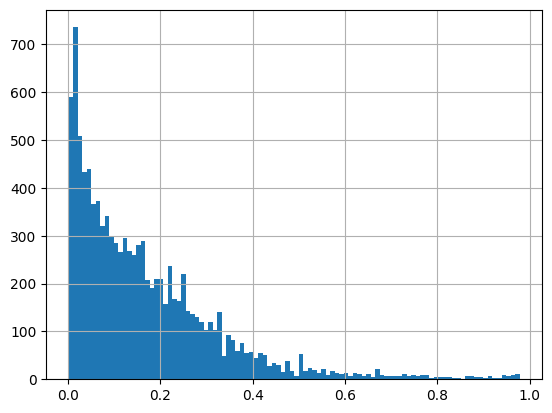

In [29]:
estimate.loc[estimate["vacant_share_mean"] > 0, "vacant_share_mean"].hist(bins=100)

In [30]:
estimate.loc[estimate["vacant_share_mean"] > 0, "vacant_share_mean"].describe()

count    10358.000000
mean         0.167139
std          0.159111
min          0.001427
25%          0.047619
50%          0.125000
75%          0.238095
max          0.978346
Name: vacant_share_mean, dtype: float64

In [18]:
vacant.loc[vacant["vacant_share_mean"] > 0, ].to_csv("vacant3.csv")